# 01_preprocessing — Build the modeling dataset (TOA → (a_φ))

**Purpose.** Construct the **canonical dataset** for modeling. Load NOMAD–SeaWiFS matchups where **TOA radiances are already Rayleigh- and Fresnel-corrected in the raw file**, compute **base-10 logs** for predictors and responses, enforce **complete-case inclusion**, and export a tidy file for the modeling notebook.

**Scope.** Predictive pipeline only — *not* an IOP inversion. Predictors are **log\(_{10}\)** of corrected TOA radiances at SeaWiFS bands (412, 443, 490, 510, 555, 670 nm). Responses are **log\(_{10}\)** phytoplankton absorption \(a_\phi\) at **443, 555, 670 nm**. **No standardization** of predictors.

---

## Inputs
- Raw NOMAD/SeaWiFS matchup file(s) with **pre-corrected TOA radiances**.
- SeaWiFS band definitions (wavelength map).

## Outputs
- `data/processed/aph_toa_ready.parquet` (analysis-ready table).
- `data/processed/schema.json` (columns, dtypes, units, band lists).
- `figs/eda/pairplot_log_toa_aph.png` (KDE diagonals + pairwise scatter).
- `results/qa/qc_summary.csv` (row counts, missingness, inclusion stats).

---

## Steps
1. **Load & harmonize** raw data (confirm corrections already applied; no re-correction).
2. **Log transforms**: compute **log\(_{10}\)** for radiances and \(a_\phi\).
3. **Selection**: require **all six** predictor bands and **all three** response bands.
4. **QA/QC**: duplicates, missingness, basic stats.
5. **EDA (first section)**: **seaborn pairplot** on **log-domain** variables (KDE diagonals).
6. **Export**: dataset + schema + EDA figures.

---

## Reproducibility
Deterministic transforms; fixed filenames; schema JSON documents columns and units.

---

## First section: quick data survey
Load raw → construct log variables → **pairplot** (KDE diagonals) to inspect distributions and pairwise structure before modeling.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as pp
from matplotlib.lines import Line2D
import cartopy.crs as ccrs
import cartopy.feature as cfeature

from scripts.data_utils import data_loader

#### Data Card
Filename: Rayleigh&Fresnel_corrected_Rrc.csv

The parameters of interest are $Rrc$, **top of atmosphere Rayleigh and Fresnel-corrected radiance* and the associated geophysical parameters, Chl and phytoplankton absorption, aph, at various wavelengths.

Phytoplankton absorption, aph, is calculated from:

$$aph = ap - ad$$

In [2]:
project_path = Path.cwd()
data_path = project_path / 'data' 
fp = '01_raw/nomad_seawifs_Rayleigh&Fresnel_corrected.csv'

In [3]:
df = data_loader(fp=data_path / fp)
df_out = df.filter(regex='(^ad|^ap[0-9]+$)')
df_out.head()

,ap405,ap411,ap443,ap455,ap465,ap489,ap510,ap520,ap530,ap550,...,ad555,ad560,ad565,ad570,ad590,ad619,ad625,ad665,ad670,ad683
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0.02880,0.03093,0.03554,0.03254,0.03137,0.02341,0.01485,0.01196,0.00955,0.00591,...,0.00136,0.00128,0.00121,0.00114,0.00091,0.00066,0.00062,0.00039,0.00037,0.00032
3,0.02313,0.02458,0.02654,0.02387,0.02274,0.01664,0.01087,0.00887,0.00714,0.00447,...,0.00082,0.00076,0.00072,0.00066,0.00051,0.00035,0.00033,0.00019,0.00017,0.00015
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
df_rrs = df.filter(regex='^sat_rrs')

In [5]:
df_rrs.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   sat_rrs412  496 non-null    float64
 1   sat_rrs443  496 non-null    float64
 2   sat_rrs490  496 non-null    float64
 3   sat_rrs510  496 non-null    float64
 4   sat_rrs555  496 non-null    float64
 5   sat_rrs670  496 non-null    float64
dtypes: float64(6)
memory usage: 23.4 KB


In [6]:
df_rrs

,sat_rrs412,sat_rrs443,sat_rrs490,sat_rrs510,sat_rrs555,sat_rrs670
0,0.00552,0.00575,0.00485,0.00345,0.00194,0.00027
1,0.00826,0.00774,0.00610,0.00350,0.00169,0.00037
2,0.00430,0.00389,0.00359,0.00279,0.00171,0.00023
3,0.00485,0.00457,0.00419,0.00305,0.00167,0.00023
4,0.01010,0.00857,0.00621,0.00389,0.00184,0.00027
...,...,...,...,...,...,...
491,0.00180,0.00298,0.00506,0.00527,0.00535,0.00086
492,0.00128,0.00155,0.00172,0.00217,0.00327,0.00094
493,0.01020,0.01161,0.01401,0.01211,0.00916,0.00116
494,0.00262,0.00348,0.00471,0.00490,0.00475,0.00074


In [14]:
df_rrs.rename(columns={k:k.split('_')[-1] for k in df_rrs.columns}, inplace=True)

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_16495/270666208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_rrs.rename(columns={k:k.split('_')[-1] for k in df_rrs.columns}, inplace=True)


In [7]:
df_toa = df.filter(regex='^Rrc')
df_toa.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Rrc_412  495 non-null    float64
 1   Rrc_443  495 non-null    float64
 2   Rrc_490  495 non-null    float64
 3   Rrc_510  495 non-null    float64
 4   Rrc_555  495 non-null    float64
 5   Rrc_670  495 non-null    float64
dtypes: float64(6)
memory usage: 23.4 KB


In [8]:
# PREPROCESS IOP
desired_lambda = [443, 555, 670]
cols = [f'{c}{i}' for c in ['ad', 'ap'] for i in desired_lambda]
df_ad_ap = df_out[cols]
df_aph = pd.DataFrame(columns = [f'aph{λ}' for λ in desired_lambda])
for λ in desired_lambda:
    df_aph[f'aph{λ}'] = df_ad_ap[f'ap{λ}'] - df_ad_ap[f'ad{λ}']
df_aph

,aph443,aph555,aph670
0,NaN,NaN,NaN
1,NaN,NaN,NaN
2,0.03078,0.00385,0.01040
3,0.02283,0.00310,0.00935
4,NaN,NaN,NaN
...,...,...,...
491,NaN,NaN,NaN
492,0.14267,0.02354,0.04603
493,NaN,NaN,NaN
494,0.04911,0.00697,0.01400


In [9]:
df_aph.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 496 entries, 0 to 495
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   aph443  168 non-null    float64
 1   aph555  166 non-null    float64
 2   aph670  168 non-null    float64
dtypes: float64(3)
memory usage: 11.8 KB


In [15]:
pd.testing.assert_index_equal(df_rrs.index, df_toa.index)
pd.testing.assert_index_equal(df_rrs.index, df_aph.index)

In [16]:
# SAVE INTERIM DATA STATE
df_aph.to_parquet(data_path / '02_reduced_columns' / 'df_aph.pqt')
df_toa.to_parquet(data_path / '02_reduced_columns' / 'df_toa.pqt')
df_rrs.to_parquet(data_path / '02_reduced_columns' / 'df_rrs.pqt')

In [17]:
# LOG TRANSFORM DATA
df_rrc_aph = pd.concat((df_toa, df_aph), axis=1)
df_log_rrc_aph = df_rrc_aph.replace(0, np.nan).transform(np.log10)
column_name_mapper = {k: f'log_{k.lower()}' for k in df_rrc_aph.columns} 
df_log_rrc_aph.rename(columns=column_name_mapper, inplace=True)
df_log_rrc_aph

,log_rrc_412,log_rrc_443,log_rrc_490,log_rrc_510,log_rrc_555,log_rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
491,-2.345332,-2.275178,-2.171985,-2.161233,-2.166044,-2.577262,NaN,NaN,NaN
492,-2.180295,-2.167633,-2.165241,-2.155715,-2.111349,-2.305298,-0.845667,-1.628194,-1.336959
493,-1.983673,-1.916870,-1.831338,-1.870797,-1.954302,-2.383724,NaN,NaN,NaN
494,-2.295468,-2.234034,-2.153897,-2.141541,-2.146016,-2.473777,-1.308830,-2.156767,-1.853872


In [18]:
df_rrs_aph = pd.concat((df_rrs, df_aph), axis=1)
df_log_rrs_aph = df_rrs_aph.replace(0, np.nan).transform(np.log10)
column_name_mapper = {k: f'log_{k}' for k in df_rrs_aph.columns} 
df_log_rrs_aph.rename(columns=column_name_mapper, inplace=True)

df_log_rrs_aph

,log_rrs412,log_rrs443,log_rrs490,log_rrs510,log_rrs555,log_rrs670,log_aph443,log_aph555,log_aph670
0,-2.258061,-2.240332,-2.314258,-2.462181,-2.712198,-3.568636,NaN,NaN,NaN
1,-2.083020,-2.111259,-2.214670,-2.455932,-2.772113,-3.431798,NaN,NaN,NaN
2,-2.366532,-2.410050,-2.444906,-2.554396,-2.767004,-3.638272,-1.511731,-2.414539,-1.982967
3,-2.314258,-2.340084,-2.377786,-2.515700,-2.777284,-3.638272,-1.641494,-2.508638,-2.029188
4,-1.995679,-2.067019,-2.206908,-2.410050,-2.735182,-3.568636,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
491,-2.744727,-2.525784,-2.295849,-2.278189,-2.271646,-3.065502,NaN,NaN,NaN
492,-2.892790,-2.809668,-2.764472,-2.663540,-2.485452,-3.026872,-0.845667,-1.628194,-1.336959
493,-1.991400,-1.935168,-1.853562,-1.916856,-2.038105,-2.935542,NaN,NaN,NaN
494,-2.581699,-2.458421,-2.326979,-2.309804,-2.323306,-3.130768,-1.308830,-2.156767,-1.853872


In [20]:
# SAVE FINAL STATE - Data is ready for study
final_path = data_path / '03_transformed'
df_log_rrc_aph.to_parquet(final_path / 'df_log_rrc_aph.pqt')
df_log_rrs_aph.to_parquet(final_path / 'df_log_rrs_aph.pqt')
df_log_rrc_aph.to_csv(final_path / 'df_log.csv', index=False)
df_log_rrs_aph.to_csv(final_path / 'df_log_rrs_aph.csv', index=False)


### Feature Engineering

In [23]:
def add_is_shelf_200m(
    df: pd.DataFrame,
    depth_col: str = "etopo2",
    flag_col: str = "is_shelf_200m",
    shelf_threshold_m: float = 200.0,
    take_abs: bool = True,
) -> pd.DataFrame:
    """
    Add a boolean 'is_shelf_200m' flag: True if depth < 200 m (continental shelf), else False.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing a bathymetry/depth column (meters).
    depth_col : str
        Name of the input depth column (e.g., 'etopo2'). If values are negative for depth,
        set take_abs=True to convert to positive meters.
    flag_col : str
        Name of the output boolean flag column.
    depth_out_col : str
        Name of the output column with depth in positive meters (for reference).
    shelf_threshold_m : float
        Threshold in meters for shelf classification (default 200 m).
    take_abs : bool
        If True, uses abs(depth) so negative bathymetry becomes positive depth.

    Returns
    -------
    pd.DataFrame
        The same DataFrame with two new columns: depth_out_col and flag_col.
    """
    if depth_col not in df.columns:
        raise KeyError(f"Depth column '{depth_col}' not found in DataFrame.")

    depth_vals = pd.to_numeric(df[depth_col], errors="coerce")
    if take_abs:
        depth_vals = depth_vals.abs()

    df[flag_col] = (depth_vals < shelf_threshold_m).where(depth_vals.notna(), np.nan)
    return df


def plot_points_map(
    df: pd.DataFrame,
    lat_col: str = "lat",
    lon_col: str = "lon",
    flag_col: str | None = None,
    legend_title: str = None,
    colors_list: list[str] | None = None,
    extent: tuple[float, float, float, float] | None = None,
    projection: ccrs.Projection = ccrs.PlateCarree(),
    markersize: float = 16,
    alpha: float = 0.8,
    coastline_resolution: str = "110m",
):
    """
    Plot point locations on a world map with optional category coloring.

    Parameters
    ----------
    df : DataFrame
        Must contain latitude/longitude columns.
    lat_col, lon_col : str
        Column names for latitude and longitude (degrees).
    flag_col : str or None
        Optional categorical column. If provided, points are colored by its values.
    colors_list : list[str] or None
        Colors to use for categories in flag_col. If None, uses a default cycle.
        Length must be >= number of unique categories.
    extent : (lon_min, lon_max, lat_min, lat_max) or None
        Map extent. If None, computed from data with padding.
    projection : cartopy.crs.Projection
        Map projection to use.
    markersize : float
        Marker size for points.
    alpha : float
        Marker transparency.
    coastline_resolution : {"110m","50m","10m"}
        Resolution for coastlines.
    """
    if lat_col not in df.columns or lon_col not in df.columns:
        raise ValueError(f"DataFrame must have '{lat_col}' and '{lon_col}' columns.")

    # Drop rows with missing coords
    d = df[[lat_col, lon_col] + ([flag_col] if flag_col and flag_col in df.columns else [])].copy()
    d = d.replace([np.inf, -np.inf], np.nan).dropna(subset=[lat_col, lon_col])

    # Compute extent if not given
    if extent is None and not d.empty:
        lon_min = np.nanpercentile(d[lon_col], 1)
        lon_max = np.nanpercentile(d[lon_col], 99)
        lat_min = np.nanpercentile(d[lat_col], 1)
        lat_max = np.nanpercentile(d[lat_col], 99)
        # add padding
        lon_pad = max(2, 0.05 * (lon_max - lon_min + 1e-9))
        lat_pad = max(2, 0.05 * (lat_max - lat_min + 1e-9))
        extent = (lon_min - lon_pad, lon_max + lon_pad, lat_min - lat_pad, lat_max + lat_pad)

    # Prepare category colors if needed
    if flag_col and flag_col in d.columns:
        cats = pd.Index(d[flag_col].astype("category").cat.categories)
        n = len(cats)
        if colors_list is None:
            # Use Matplotlib's default property cycle (repeat if needed)
            default_cycle = plt.rcParams["axes.prop_cycle"].by_key().get("color", [])
            if not default_cycle:
                default_cycle = [f"C{i}" for i in range(n)]
            if len(default_cycle) < n:
                # repeat to match length
                times = int(np.ceil(n / len(default_cycle)))
                default_cycle = (default_cycle * times)[:n]
            colors = dict(zip(cats, default_cycle))
        else:
            if len(colors_list) < n:
                raise ValueError(f"colors_list has {len(colors_list)} colors, but needs ≥ {n}.")
            colors = dict(zip(cats, colors_list[:n]))
    else:
        cats, colors = None, None

    # Create figure
    fig = pp.figure(figsize=(10, 6), dpi=120)
    ax = pp.axes(projection=projection)

    # Background & features
    ax.add_feature(cfeature.LAND, facecolor="0.9")
    ax.add_feature(cfeature.OCEAN, facecolor="white")
    ax.add_feature(cfeature.COASTLINE.with_scale(coastline_resolution), linewidth=0.5)
    ax.add_feature(cfeature.BORDERS.with_scale(coastline_resolution), linewidth=0.4)
    gl = ax.gridlines(draw_labels=True, xlocs=np.arange(-180, 181, 30), ylocs=np.arange(-80, 81, 20))
    gl.right_labels = False
    gl.top_labels = False

    # Set extent if available
    if extent is not None:
        ax.set_extent(extent, crs=ccrs.PlateCarree())

    # Plot points
    if cats is None:
        ax.scatter(
            d[lon_col].values, d[lat_col].values,
            s=markersize, alpha=alpha,
            marker="o",
            transform=ccrs.PlateCarree(),
        )
    else:
        handles = []
        labels = []
        for cat in cats:
            sel = d[d[flag_col].astype("category") == cat]
            h = ax.scatter(
                sel[lon_col].values, sel[lat_col].values,
                s=markersize, alpha=alpha,
                marker="o",
                edgecolor='k',
                transform=ccrs.PlateCarree(),
                label=str(cat),
                color=colors[cat],
            )
            handles.append(h)
            labels.append(str(cat))
        if legend_title is None:
            legend_title = flag_col
        ax.legend(handles=handles, labels=labels, title=legend_title, loc="lower left", frameon=True)

    ax.set_title("Station Locations", pad=8)
    return fig, ax


In [24]:
import re

def add_avw_classes_single_prefix(
    df: pd.DataFrame,
    prefix: str,                 # e.g., "Rrs" or "Rrc"
    n_classes: int = 3,          # clear / mid / complex by default
    wl_min: float = 380.0,
    wl_max: float = 750.0,
    avw_col: str = "AVW_nm",
    class_col: str = "avw_class",
    labels_ascending: bool = True,
    strict: bool = False,        # if True, raise if no spectral cols found
) -> pd.DataFrame:
    """
    Compute AVW (Apparent Visible Wavelength) from columns with a single prefix
    and assign AVW classes via quantile bins.

    Expected spectral columns look like:
      '<prefix>_443' or '<prefix>443' (case-insensitive)
    Example: 'Rrc_412', 'Rrc443', 'Rrs_555'

    AVW = sum(lambda * R(lambda)) / sum(R(lambda)) over wl_min..wl_max (nm).

    Parameters
    ----------
    df : pd.DataFrame
        Input data with spectral columns.
    prefix : str
        Single column prefix to use (e.g., 'Rrs' or 'Rrc').
    n_classes : int
        Number of quantile bins to form (default 3).
    wl_min, wl_max : float
        Wavelength bounds in nm for inclusion.
    avw_col : str
        Output column name for AVW (nanometers).
    class_col : str
        Output column name for AVW class labels (1..n_classes).
    labels_ascending : bool
        If True, class 1 = lowest AVW (bluer/clearer); highest = greener/complex.
    strict : bool
        If True and no spectral columns are found, raises ValueError.

    Returns
    -------
    pd.DataFrame
        With added columns: `AVW_nm` and `avw_class`.
    """
    pat = re.compile(rf"^{re.escape(prefix)}_?(\d+(\.\d+)?)$", flags=re.IGNORECASE)

    cols, wls = [], []
    for c in df.columns:
        m = pat.match(str(c))
        if m:
            wl = float(m.group(1))
            if wl_min <= wl <= wl_max:
                cols.append(c)
                wls.append(wl)

    if not cols:
        if strict:
            raise ValueError(f"No spectral columns found for prefix '{prefix}'.")
        # Graceful no-op with NaNs
        df[avw_col] = np.nan
        df[class_col] = np.nan
        return df

    wls = np.asarray(wls, dtype=float)
    R = df[cols].apply(pd.to_numeric, errors="coerce").to_numpy(dtype=float)  # (n, k)

    num = np.nansum(R * wls[None, :], axis=1)
    den = np.nansum(R, axis=1)
    avw = np.where((den != 0) & np.isfinite(num) & np.isfinite(den), num / den, np.nan)

    df[avw_col] = avw

    # Quantile classes 1..n; low AVW -> 1 if labels_ascending=True
    try:
        labels = list(range(1, n_classes + 1))
        if not labels_ascending:
            labels = labels[::-1]
        df[class_col] = pd.qcut(df[avw_col], q=n_classes, labels=labels)
    except ValueError:
        # Not enough unique values to form quantiles
        df[class_col] = np.nan

    return df

In [25]:
df_toa

,Rrc_412,Rrc_443,Rrc_490,Rrc_510,Rrc_555,Rrc_670
0,0.012088,0.012417,0.011739,0.010579,0.009110,0.006655
1,0.010525,0.010636,0.009614,0.007913,0.006224,0.004794
2,0.004443,0.004387,0.004240,0.003686,0.002646,0.001177
3,0.005869,0.005866,0.005535,0.004643,0.003326,0.001747
4,0.009464,0.008968,0.007719,0.005974,0.004161,0.002517
...,...,...,...,...,...,...
491,0.004515,0.005307,0.006730,0.006899,0.006823,0.002647
492,0.006602,0.006798,0.006835,0.006987,0.007738,0.004951
493,0.010383,0.012110,0.014746,0.013465,0.011110,0.004133
494,0.005064,0.005834,0.007016,0.007219,0.007145,0.003359


In [26]:
d_temp_rrc = add_avw_classes_single_prefix(df_toa, prefix='Rrc', n_classes=3, strict=True)['avw_class']

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_16495/1575699455.py:72: RuntimeWarning: invalid value encountered in divide
  avw = np.where((den != 0) & np.isfinite(num) & np.isfinite(den), num / den, np.nan)
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_16495/1575699455.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[avw_col] = avw
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_16495/1575699455.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[class_col] =

In [27]:
d_temp_rrc

0        2
1        1
2        1
3        1
4        1
      ... 
491      3
492      3
493      2
494      3
495    NaN
Name: avw_class, Length: 496, dtype: category
Categories (3, int64): [1 < 2 < 3]

In [29]:
d_temp_rrs = add_avw_classes_single_prefix(df_rrs, prefix='rrs', n_classes=3, strict=True)['avw_class']

/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_16495/1575699455.py:74: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[avw_col] = avw
/var/folders/c9/p_x94m2j357984db558g2n9m0000gn/T/ipykernel_16495/1575699455.py:81: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df[class_col] = pd.qcut(df[avw_col], q=n_classes, labels=labels)


In [30]:
d_temp_rrs

0      1
1      1
2      1
3      1
4      1
      ..
491    3
492    3
493    2
494    3
495    3
Name: avw_class, Length: 496, dtype: category
Categories (3, int64): [1 < 2 < 3]

In [35]:
df_env = df.loc[df_toa.index, ['lat', 'lon', 'etopo2']].copy()
df_env = add_is_shelf_200m(df_env, depth_col='etopo2')
df_env

,lat,lon,etopo2,is_shelf_200m
0,39.2900,25.1100,462,False
1,-61.4500,-62.2990,3549,False
2,-61.2900,-56.2900,330,False
3,-60.9990,-56.4980,2193,False
4,24.1392,-20.9995,4369,False
...,...,...,...,...
491,26.1518,-82.0972,12,True
492,27.5394,-82.8044,7,True
493,25.2882,-81.8809,6,True
494,25.4736,-81.7759,34,True


In [36]:
df_env['avw_rrc'] = d_temp_rrc.values

In [37]:
df_env['avw_rrs'] = d_temp_rrs.values

In [38]:
# Number of matching AVW classes between Rrs and Rrc
df_env[['avw_rrs','avw_rrc']].dropna().pipe(lambda d: (d.iloc[:,0] == d.iloc[:,1]).sum())

354

In [39]:
# Number of non-matching AVW classes between Rrs and Rrc
df_env[['avw_rrs','avw_rrc']].dropna().pipe(lambda d: (d.iloc[:,0] != d.iloc[:,1]).sum())

140

In [40]:
df_env[['avw_rrs','avw_rrc']].dropna().pipe(lambda d: (d.iloc[:,0].astype('int') - d.iloc[:,1].astype('int'))).value_counts()

 0    354
 1     73
-1     60
-2      7
Name: count, dtype: int64

In [41]:
df_env.avw_rrs.value_counts()

avw_rrs
1    166
2    165
3    165
Name: count, dtype: int64

In [42]:
df_env[['avw_rrs','is_shelf_200m']].dropna().pipe(lambda d: (d.iloc[:,0].astype('int') * (d.iloc[:,1].astype('int')+1).pow(2))).value_counts()

12    130
8     111
1      94
4      72
2      54
3      35
Name: count, dtype: int64

avw | shelf (<200m)<br>
1      x ( 0  + 1) ^ 2 =   1: blue & not shelf <br>
2      x ( 0...        =   2: green & not-shelf <br>
3      x ( 0...        =   3: brown & not shelf <br>
1      x ( 1...        =   4: blue & shelf <br>
2      x ( 1...        =   8: green & shelf <br>
3      x ( 1...        =  12: brown & shelf <br>

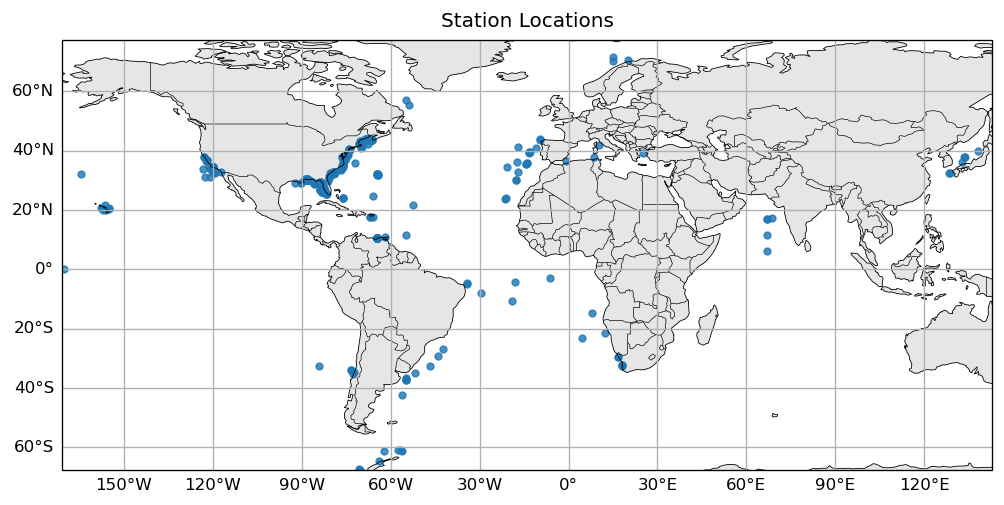

In [43]:
# Simple: all points one color
fig, ax = plot_points_map(df_env, lat_col="lat", lon_col="lon")


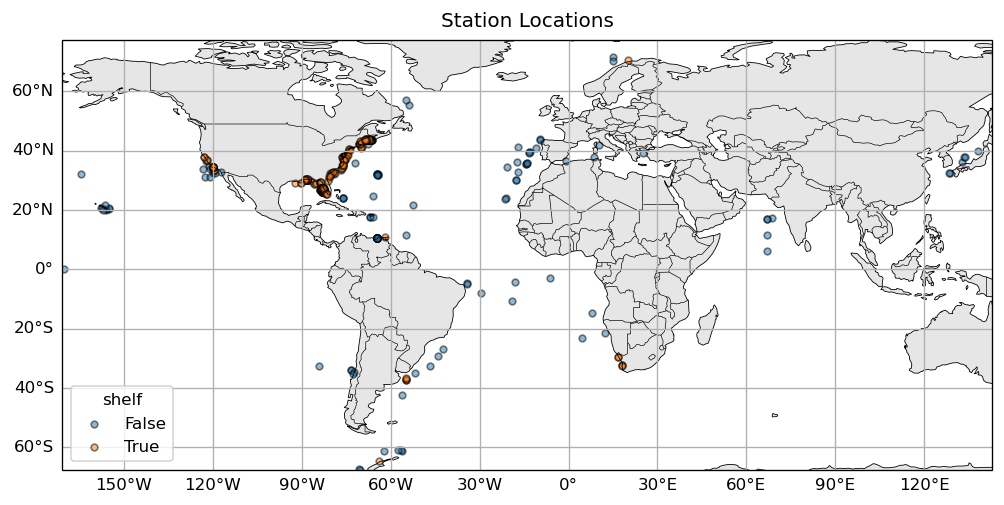

In [44]:

# With a coastal flag column (e.g., 'is_shelf_200m' from our enriched file)
fig, ax = plot_points_map(
    df_env,
    lat_col="lat", lon_col="lon",
    flag_col="is_shelf_200m",
    legend_title='shelf',                 # boolean or categorical
    colors_list=["#1f77b4", "#ff7f0e"], alpha=0.5      # coastal=False, True
)


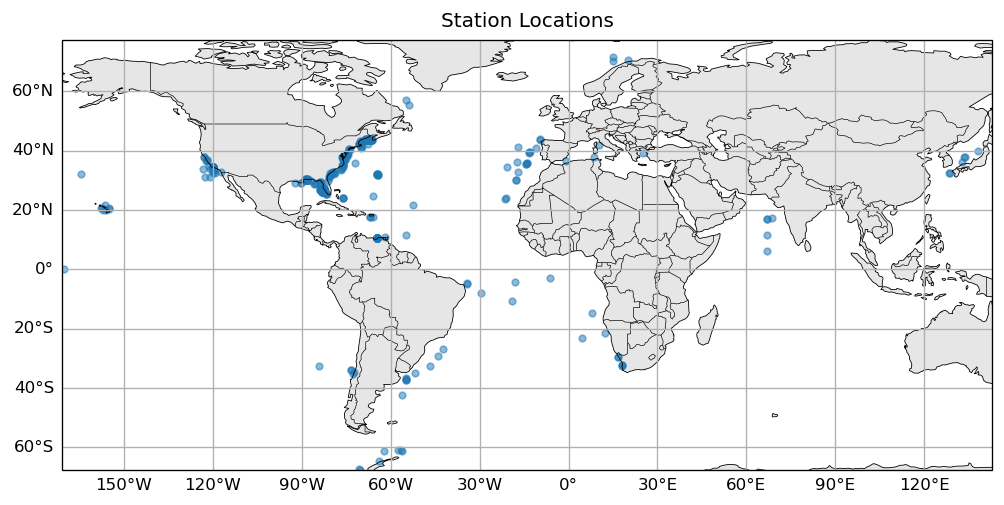

In [45]:
# With a coastal flag column (e.g., 'is_shelf_200m' from our enriched file)
fig_avw_rrs, ax = plot_points_map(
    df_env,
    lat_col="lat", lon_col="lon",
    flag_col="avw_Rrs",
    legend_title='AVW (Rrs)',                 # boolean or categorical
    colors_list=["blue", "green", "brown"], alpha=0.5      # coastal=False, True
)

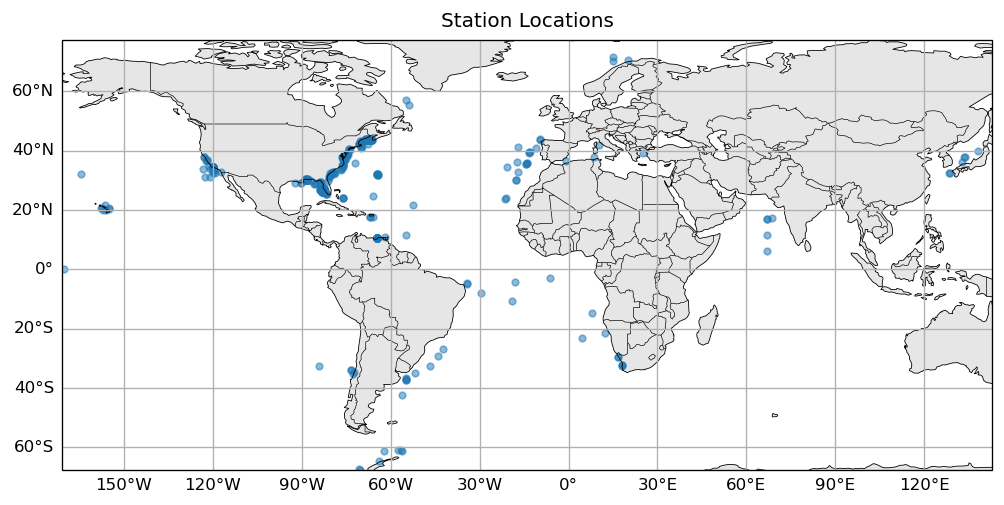

In [46]:

# With a coastal flag column (e.g., 'is_shelf_200m' from our enriched file)
fig_avw_rrc, ax = plot_points_map(
    df_env,
    lat_col="lat", lon_col="lon",
    flag_col="avw_Rrc",
    legend_title='AVW(Rrc)',                 # boolean or categorical
    colors_list=["blue", "green", "brown"], alpha=0.5      # coastal=False, True
)

In [47]:
def combine_shelf_avw(
    df: pd.DataFrame,
    shelf_col: str = "is_shelf_200m",
    avw_col: str = "avw_class",
    out_col: str = "shelf_avw_cat",
):
    # map shelf flag -> text
    side = pd.Series(pd.NA, index=df.index, dtype="string")
    side = side.mask(df[shelf_col] == True,  "coastal")
    side = side.mask(df[shelf_col] == False, "off_shelf")

    # stringify AVW class (handles categorical or numeric, keeps NA)
    avw_str = df[avw_col].astype("Int64").astype("string")

    # combine, keep NA if either piece is NA
    combo = pd.Series(pd.NA, index=df.index, dtype="string")
    mask = side.notna() & avw_str.notna()
    combo.loc[mask] = side.loc[mask] + ":AVW" + avw_str.loc[mask]

    # make it an ordered categorical with all 6 combos
    cats = [
        "coastal:AVW1", "coastal:AVW2", "coastal:AVW3",
        "off_shelf:AVW1", "off_shelf:AVW2", "off_shelf:AVW3",
    ]
    df[out_col] = pd.Categorical(combo, categories=cats, ordered=True)
    return df


In [49]:
df_env = combine_shelf_avw(df_env, avw_col="avw_rrs", out_col='shelf_avw_rrs_cat')
df_env = combine_shelf_avw(df_env, avw_col="avw_rrc", out_col='shelf_avw_rrc_cat')

In [50]:
df_env.shelf_avw_rrs_cat.value_counts()

shelf_avw_rrs_cat
coastal:AVW3      130
coastal:AVW2      111
off_shelf:AVW1     94
coastal:AVW1       72
off_shelf:AVW2     54
off_shelf:AVW3     35
Name: count, dtype: int64

In [51]:
df_env.shelf_avw_rrc_cat.value_counts()

shelf_avw_rrc_cat
coastal:AVW3      128
coastal:AVW2      107
off_shelf:AVW1     89
coastal:AVW1       76
off_shelf:AVW2     57
off_shelf:AVW3     37
Name: count, dtype: int64

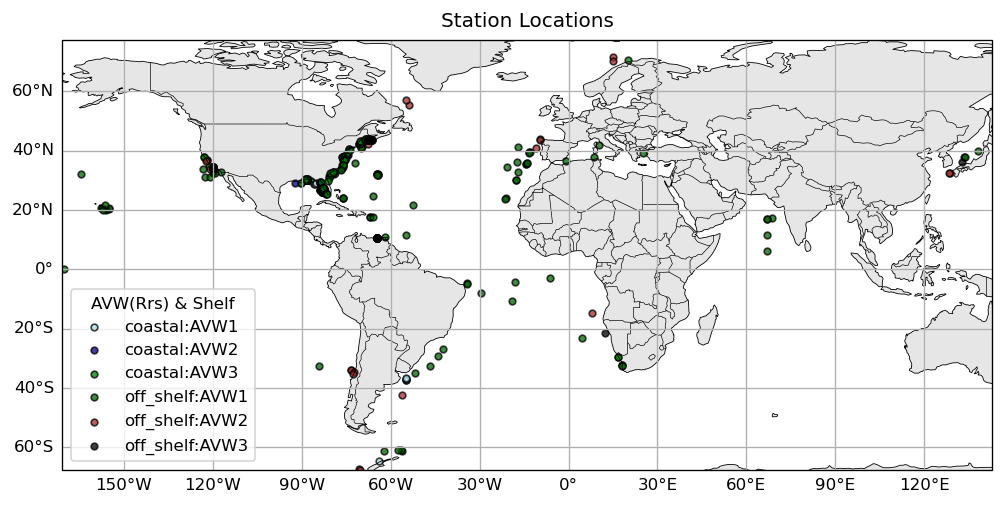

In [52]:
# With a coastal flag column (e.g., 'is_shelf_200m' from our enriched file)
fig_avw_rrs_shelf, ax = plot_points_map(
    df_env,
    lat_col="lat", lon_col="lon",
    flag_col="shelf_avw_rrs_cat",
    legend_title='AVW(Rrs) & Shelf',                 # boolean or categorical
    colors_list=["#ADD8E6", "#00008B", "#008000", "#006400", "#A52A2A", "#000000"], alpha=0.75      # coastal=False, True
)

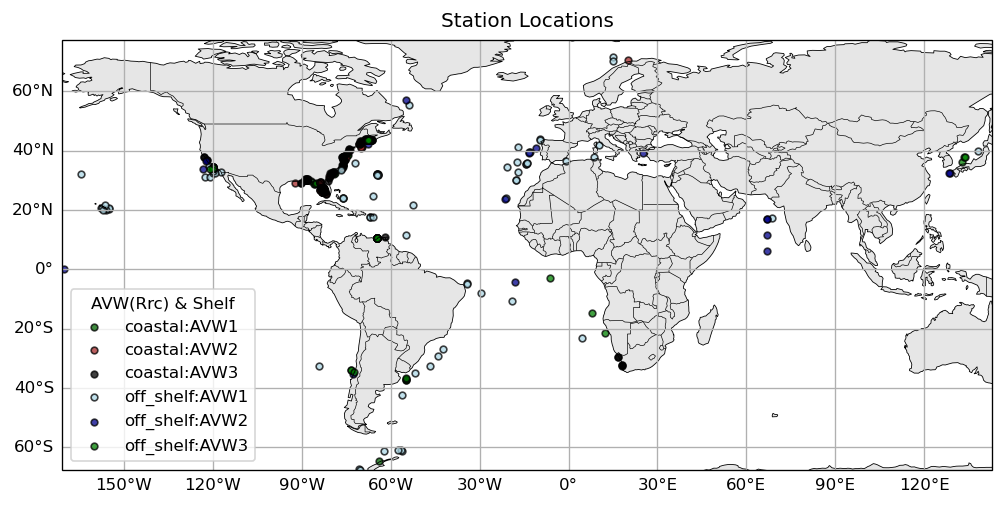

In [53]:
# With a coastal flag column (e.g., 'is_shelf_200m' from our enriched file)
fig_avw_rrc_shelf, ax = plot_points_map(
    df_env,
    lat_col="lat", lon_col="lon",
    flag_col="shelf_avw_rrc_cat",
    legend_title='AVW(Rrc) & Shelf',                 # boolean or categorical
    colors_list=["#006400", "#A52A2A", "#000000", "#ADD8E6", "#00008B", "#008000"], alpha=0.75   )   # coastal=False, True

In [54]:
df_env.shelf_avw_rrc_cat.value_counts()

shelf_avw_rrc_cat
coastal:AVW3      128
coastal:AVW2      107
off_shelf:AVW1     89
coastal:AVW1       76
off_shelf:AVW2     57
off_shelf:AVW3     37
Name: count, dtype: int64

In [55]:
df_env.shelf_avw_rrs_cat.value_counts()

shelf_avw_rrs_cat
coastal:AVW3      130
coastal:AVW2      111
off_shelf:AVW1     94
coastal:AVW1       72
off_shelf:AVW2     54
off_shelf:AVW3     35
Name: count, dtype: int64

<Axes: xlabel='shelf_avw_rrc_cat'>

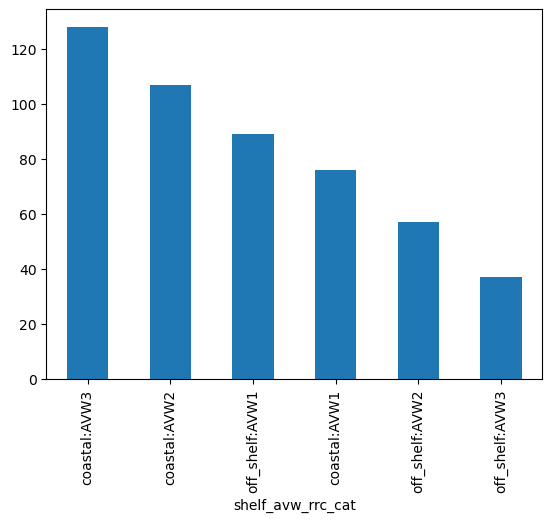

In [56]:
df_env.shelf_avw_rrc_cat.value_counts().plot(kind='bar')

<Axes: xlabel='shelf_avw_rrs_cat'>

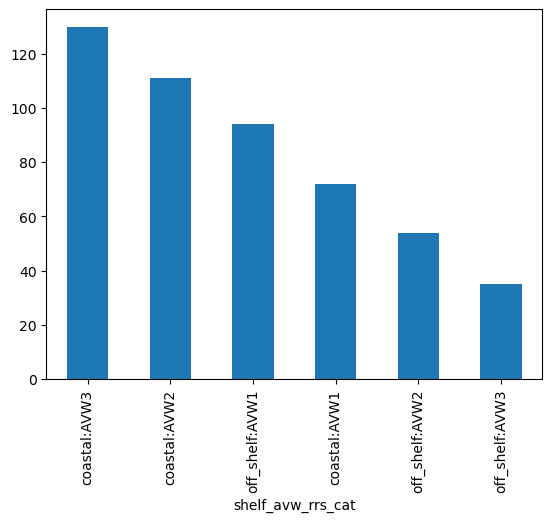

In [57]:
df_env.shelf_avw_rrs_cat.value_counts().plot(kind='bar')

In [58]:
from scripts.pnas_utils import save_pnas, set_pnas_style
set_pnas_style()

In [59]:
save_pnas(fig, path=project_path / 'figs' /'si'/ 'station_map.pdf')
save_pnas(fig, path=project_path / 'figs' /'portfolio'/ 'station_map.png')

In [60]:
save_pnas(fig_avw_rrs, path=project_path / 'figs' /'si'/ 'station_map_avw_rrs.pdf')
save_pnas(fig_avw_rrs, path=project_path / 'figs' /'portfolio'/ 'station_map_avw_rrs.png')

In [61]:
save_pnas(fig_avw_rrc, path=project_path / 'figs' /'si'/ 'station_map_avw_rrc.pdf')
save_pnas(fig_avw_rrc, path=project_path / 'figs' /'portfolio'/ 'station_map_avw_rrc.png')

In [79]:
df_env.to_parquet(data_path / '03_transformed' / 'df_env.pqt')

In [63]:
df_env.info()

<class 'pandas.core.frame.DataFrame'>
Index: 496 entries, 0 to 495
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   lat                496 non-null    float64 
 1   lon                496 non-null    float64 
 2   etopo2             496 non-null    int64   
 3   is_shelf_200m      496 non-null    bool    
 4   avw_rrc            494 non-null    category
 5   avw_rrs            496 non-null    category
 6   shelf_avw_rrs_cat  496 non-null    category
 7   shelf_avw_rrc_cat  494 non-null    category
dtypes: bool(1), category(4), float64(2), int64(1)
memory usage: 18.6 KB


###  Combining data for causal analysis where treatments are 
1) only Fresnel and Raleigh correction applied (Rrc),
2) full atmospheric correction applied (Rrs)

In [64]:
df_log_rrc_aph

,log_rrc_412,log_rrc_443,log_rrc_490,log_rrc_510,log_rrc_555,log_rrc_670,log_aph443,log_aph555,log_aph670
0,-1.917660,-1.905994,-1.930380,-1.975543,-2.040501,-2.176858,NaN,NaN,NaN
1,-1.977774,-1.973214,-2.017116,-2.101675,-2.205903,-2.319302,NaN,NaN,NaN
2,-2.352334,-2.357865,-2.372588,-2.433492,-2.577377,-2.929113,-1.511731,-2.414539,-1.982967
3,-2.231428,-2.231674,-2.256908,-2.333192,-2.478052,-2.757732,-1.641494,-2.508638,-2.029188
4,-2.023925,-2.047304,-2.112433,-2.223764,-2.380771,-2.599169,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
491,-2.345332,-2.275178,-2.171985,-2.161233,-2.166044,-2.577262,NaN,NaN,NaN
492,-2.180295,-2.167633,-2.165241,-2.155715,-2.111349,-2.305298,-0.845667,-1.628194,-1.336959
493,-1.983673,-1.916870,-1.831338,-1.870797,-1.954302,-2.383724,NaN,NaN,NaN
494,-2.295468,-2.234034,-2.153897,-2.141541,-2.146016,-2.473777,-1.308830,-2.156767,-1.853872


In [72]:
df_merged = pd.merge(df_log_rrc_aph, df_log_rrs_aph, right_index=True, left_index=True, suffixes=('_remove', ''))
df_merged.drop(df_merged.filter(like='_remove'), axis=1, inplace=True)
df_merged.dropna(inplace=True)

In [73]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 2 to 494
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   log_rrc_412  148 non-null    float64
 1   log_rrc_443  148 non-null    float64
 2   log_rrc_490  148 non-null    float64
 3   log_rrc_510  148 non-null    float64
 4   log_rrc_555  148 non-null    float64
 5   log_rrc_670  148 non-null    float64
 6   log_rrs412   148 non-null    float64
 7   log_rrs443   148 non-null    float64
 8   log_rrs490   148 non-null    float64
 9   log_rrs510   148 non-null    float64
 10  log_rrs555   148 non-null    float64
 11  log_rrs670   148 non-null    float64
 12  log_aph443   148 non-null    float64
 13  log_aph555   148 non-null    float64
 14  log_aph670   148 non-null    float64
dtypes: float64(15)
memory usage: 18.5 KB


In [76]:
df_merged.to_parquet(final_path / 'df_log_rrc_rrs_aph.pqt')
df_merged.to_csv(final_path / 'df_log_rrc_rrs_aph.csv', index=False)

Map Merged Dataframe Stations:

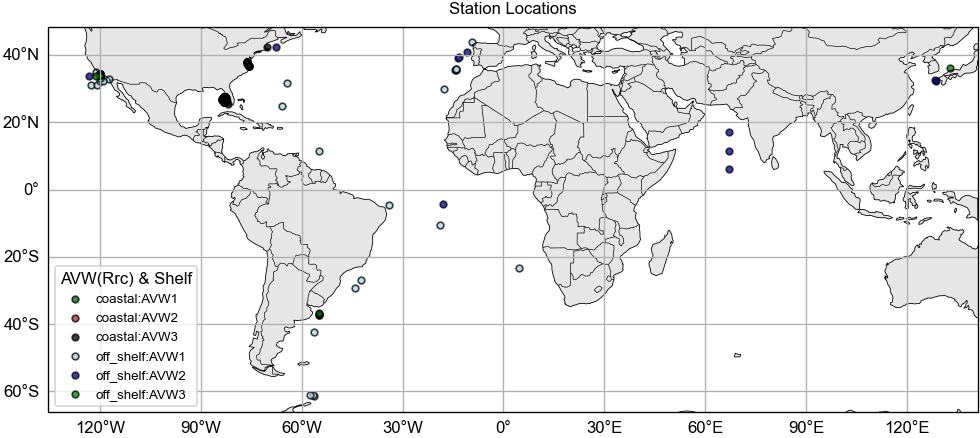

In [ ]:
# With a coastal flag column (e.g., 'is_shelf_200m' from enriched file)
fig_avw_rrc_shelf, ax = plot_points_map(
    df_env.loc[df_merged.index],
    lat_col="lat", lon_col="lon",
    flag_col="shelf_avw_rrc_cat",
    legend_title='AVW(Rrc) & Shelf',                 # boolean or categorical
    colors_list=["#006400", "#A52A2A", "#000000", "#ADD8E6", "#00008B", "#008000"],
     alpha=0.75   )   # coastal=False, True

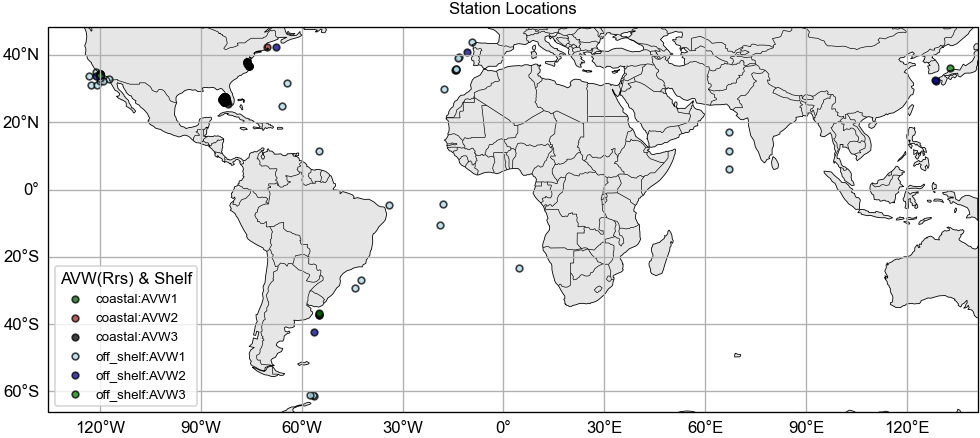

In [ ]:
# With a coastal flag column (e.g., 'is_shelf_200m' from enriched file)
fig_avw_rrc_shelf, ax = plot_points_map(
    df_env.loc[df_merged.index],
    lat_col="lat", lon_col="lon",
    flag_col="shelf_avw_rrs_cat",
    legend_title='AVW(Rrs) & Shelf',                 # boolean or categorical
    colors_list=["#006400", "#A52A2A", "#000000", "#ADD8E6", "#00008B", "#008000"],
     alpha=0.75   )   # coastal=False, True